In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio
pio.renderers.default = "browser"

In [210]:
SCDs = pd.read_csv('../../../data/SCDs.csv')

In [211]:
transect_df = pd.read_csv('../../../data/Transect.csv')
transect_df.columns = ['Stop', 'Lat', 'Long', 'Res 1', 'Res 2', 'Res 3', 'Res 4', 'Res 5', 'Res 6', 'Res 7', 'Res 8']

In [212]:
val_cols = ['Res 1', 'Res 2', 'Res 3', 'Res 4', 'Res 5', 'Res 6', 'Res 7', 'Res 8']
transect_df['Avg_H2'] = transect_df[val_cols].mean(axis=1)
transect_df['Lat'] = transect_df['Lat'].apply(lambda x: float(str(x).replace(' ', '')[:-1]))
transect_df['Long'] = transect_df['Long'].apply(lambda x: float(str(x).replace(' ', '')[:-1]))
transect_df['Max'] = transect_df[val_cols].max(axis=1)


In [213]:
transect_df

,Stop,Lat,Long,Res 1,Res 2,Res 3,Res 4,Res 5,Res 6,Res 7,Res 8,Avg_H2,Max
0,14,511055.00,32446.00,3,3,3,3,NaN,NaN,NaN,NaN,3.00,3.0
1,15,511054.00,32421.00,5,46,41,22,NaN,NaN,NaN,NaN,28.50,46.0
2,16,511042.00,32318.00,2,2,1,40,NaN,NaN,NaN,NaN,11.25,40.0
3,17,511057.00,32257.00,4,5,13,9,NaN,NaN,NaN,NaN,7.75,13.0
4,18,511101.00,32244.00,1,3,1,2,NaN,NaN,NaN,NaN,1.75,3.0
5,19,511101.00,32238.00,3,3,3,0,NaN,NaN,NaN,NaN,2.25,3.0
6,20,511101.00,32226.00,1,3,2,13,NaN,NaN,NaN,NaN,4.75,13.0
7,21,511058.00,32200.00,3,3,2,7,NaN,NaN,NaN,NaN,3.75,7.0
8,22,511052.18,32113.11,4,5,2,1,NaN,NaN,NaN,NaN,3.00,5.0
9,23,511052.12,32032.74,0,2,1,6,NaN,NaN,NaN,NaN,2.25,6.0


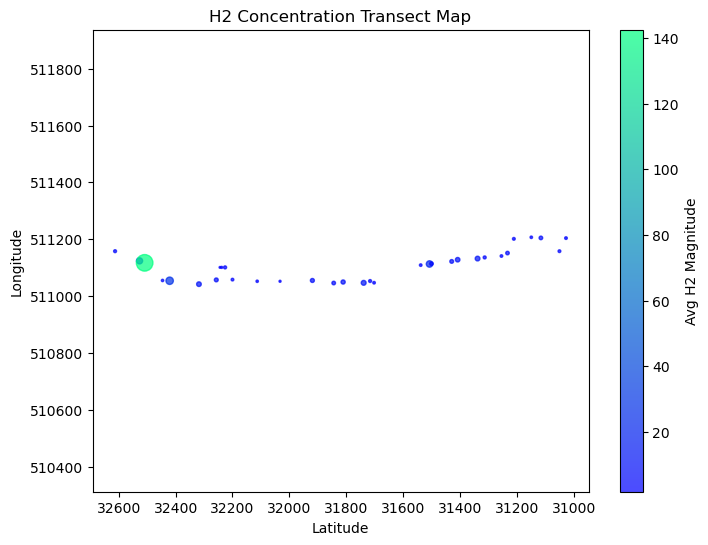

In [231]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6)) 

plt.scatter(
    y=transect_df['Lat'], 
    x=transect_df['Long'], 
    s=transect_df['Avg_H2'], 
    c=transect_df['Avg_H2'], 
    cmap='winter', 
    alpha=0.7, 
)

plt.gca().invert_xaxis()
plt.axis('equal')

plt.colorbar(label='Avg H2 Magnitude')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.title('H2 Concentration Transect Map')

plt.show()


In [216]:
transect_df_l_to_r = transect_df.sort_values('Long')

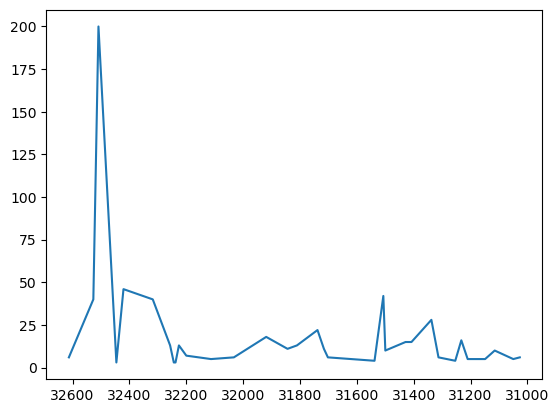

In [217]:
plt.plot(transect_df_l_to_r['Long'], transect_df_l_to_r['Max'])
plt.gca().invert_xaxis()

In [ ]:
import numpy as np
import plotly.express as px

def dms_to_decimal(dms_num):
    if np.isnan(dms_num):
        return np.nan
    
    # Pad to 6 digits 
    s = f"{int(dms_num):06d}"
    
    degrees = int(s[:-4])
    minutes = int(s[-4:-2])
    seconds = int(s[-2:])
    
    return degrees + (minutes / 60.0) + (seconds / 3600.0)

# convert and calculations
transect_df["Lat_DD"] = transect_df["Lat"].apply(dms_to_decimal)
transect_df["Long_DD"] = -1 * transect_df["Long"].apply(dms_to_decimal)
transect_df['LogH2Avg'] = transect_df['Avg_H2'].apply(np.log1p)
transect_df['logMax'] = transect_df['Max'].apply(np.log1p)

center_lat = transect_df["Lat_DD"].mean()
center_lon = transect_df["Long_DD"].mean()

fig = px.scatter_mapbox(
    transect_df, 
    lat="Lat_DD", 
    lon="Long_DD", 
    size="Max",             
    zoom=11,       
    color_continuous_scale='winter',         
    title="H2 Concentration Transect Map",
)

fig.update_layout(
    mapbox_style="open-street-map",
    mapbox_center={"lat": center_lat, "lon": center_lon}
)
fig.show()


/var/folders/fx/yls4l5xd4cdgs4b7gy2xpdv40000gn/T/ipykernel_41347/62499594.py:30: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


In [220]:
# all measurements.

mean_all_stops = []
max_all_stops = []
median_all_stops = []

mean_all_stops.extend(list(transect_df['Avg_H2']))
max_all_stops.extend(list(transect_df['Max']))
median_all_stops.extend(list(transect_df[val_cols].median(axis=1)))

scd_val_cols = [f'Res {i+1}' for i in range(0, 15)]
mean_all_stops.extend(list(SCDs['Average']))
max_all_stops.extend(list(SCDs['Max']))
median_all_stops.extend(list(SCDs[scd_val_cols].median(axis=1)))

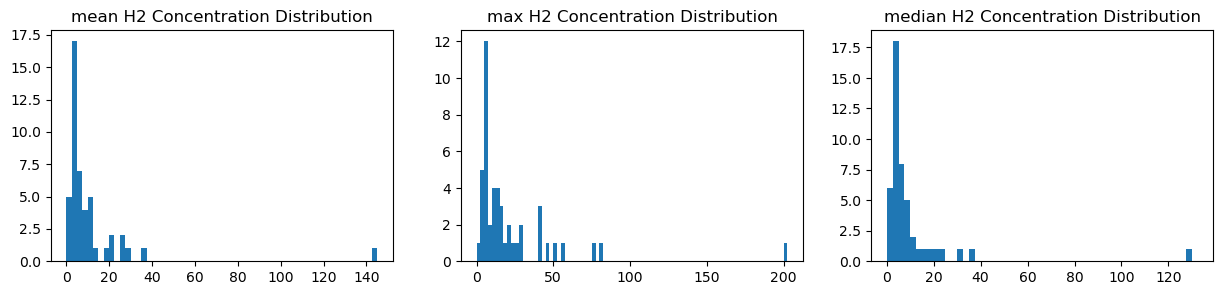

In [221]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
metrics = [mean_all_stops, max_all_stops, median_all_stops]
titles = ['mean', 'max', 'median']

for ax, metric, ttl in zip(axes, metrics, titles):
    bins = np.arange(0, max(metric)+5, 2.5)
    ax.hist(metric, bins=bins)
    ax.set_title(f'{ttl} H2 Concentration Distribution')
    